In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 3.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-10

In [2]:
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [3]:
noisy_dir = '/kaggle/input/dataset2/dataset/noisy'
clean_dir = '/kaggle/input/dataset2/dataset/clean'

In [4]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

In [5]:
class NoisyDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform = None):
        self.noisy_dir = noisy_dir
        self.clean_dir = clean_dir
        self.images = sorted([f for f in os.listdir(noisy_dir) if f.lower().endswith(('.png', '.jpg'))])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        noisy_image = Image.open(os.path.join(self.noisy_dir, self.images[idx])).convert('L')
        clean_image = Image.open(os.path.join(self.clean_dir, self.images[idx])).convert('L')

        if self.transform:
            noisy_image = self.transform(noisy_image)
            clean_image = self.transform(clean_image)

        return noisy_image, clean_image

In [6]:
dataset = NoisyDataset(noisy_dir, clean_dir, transform)
dataloader = DataLoader(dataset, batch_size = 8, shuffle = True)

In [7]:
class Unet(nn.Module):
  def __init__(self):
    super().__init__()

    def convblock(in_ch, out_ch):
      return nn.Sequential(
          nn.Conv2d(in_ch, out_ch, 3, padding = 1),
          nn.BatchNorm2d(out_ch),
          nn.ReLU(inplace = True),
          nn.Conv2d(out_ch, out_ch, 3, padding = 1),
          nn.BatchNorm2d(out_ch),
          nn.ReLU(inplace = True),
      )

    self.enc1 = convblock(1, 64)
    self.enc2 = convblock(64, 128)
    self.enc3 = convblock(128, 256)

    self.pool = nn.MaxPool2d(2)

    self.middle = convblock(256, 512)

    self.up3 = nn.ConvTranspose2d(512, 256, 2, stride = 2)
    self.dec3 = convblock(512, 256)

    self.up2 = nn.ConvTranspose2d(256, 128, 2, stride = 2)
    self.dec2 = convblock(256, 128)
    self.up1 = nn.ConvTranspose2d(128, 64, 2, stride = 2)
    self.dec1 = convblock(128, 64)

    self.out = nn.Conv2d(64, 1, 1)

  def forward(self, x):
    e1 = self.enc1(x)
    e2 = self.enc2(self.pool(e1))
    e3 = self.enc3(self.pool(e2))

    m = self.middle(self.pool(e3))

    d3 = self.dec3(torch.cat((self.up3(m), e3), dim = 1))
    d2 = self.dec2(torch.cat((self.up2(d3), e2), dim = 1))
    d1 = self.dec1(torch.cat((self.up1(d2), e1), dim = 1))

    return torch.sigmoid(self.out(d1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Unet().to(device)

In [8]:
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
criterion = nn.L1Loss()

In [9]:
def train_model(model, dataloader, optimizer, num_epochs = 400):

  for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for noisy, clean in dataloader:
      noisy, clean = noisy.to(device), clean.to(device)
      output = model(noisy)
      loss = criterion(output, clean)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss += loss.item()

    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {total_loss / len(dataloader):.4f}')

train_model(model, dataloader, optimizer, num_epochs = 400)

torch.save(model.state_dict(), 'model.pt')

Epoch 1/400, Loss: 0.3039
Epoch 2/400, Loss: 0.2710
Epoch 3/400, Loss: 0.2505
Epoch 4/400, Loss: 0.2323
Epoch 5/400, Loss: 0.2171
Epoch 6/400, Loss: 0.2026
Epoch 7/400, Loss: 0.1907
Epoch 8/400, Loss: 0.1785
Epoch 9/400, Loss: 0.1647
Epoch 10/400, Loss: 0.1557
Epoch 11/400, Loss: 0.1459
Epoch 12/400, Loss: 0.1397
Epoch 13/400, Loss: 0.1375
Epoch 14/400, Loss: 0.1354
Epoch 15/400, Loss: 0.1318
Epoch 16/400, Loss: 0.1292
Epoch 17/400, Loss: 0.1251
Epoch 18/400, Loss: 0.1214
Epoch 19/400, Loss: 0.1197
Epoch 20/400, Loss: 0.1190
Epoch 21/400, Loss: 0.1174
Epoch 22/400, Loss: 0.1128
Epoch 23/400, Loss: 0.1111
Epoch 24/400, Loss: 0.1084
Epoch 25/400, Loss: 0.1064
Epoch 26/400, Loss: 0.1038
Epoch 27/400, Loss: 0.1023
Epoch 28/400, Loss: 0.1012
Epoch 29/400, Loss: 0.0992
Epoch 30/400, Loss: 0.0975
Epoch 31/400, Loss: 0.0958
Epoch 32/400, Loss: 0.0946
Epoch 33/400, Loss: 0.0931
Epoch 34/400, Loss: 0.0915
Epoch 35/400, Loss: 0.0897
Epoch 36/400, Loss: 0.0888
Epoch 37/400, Loss: 0.0880
Epoch 38/4

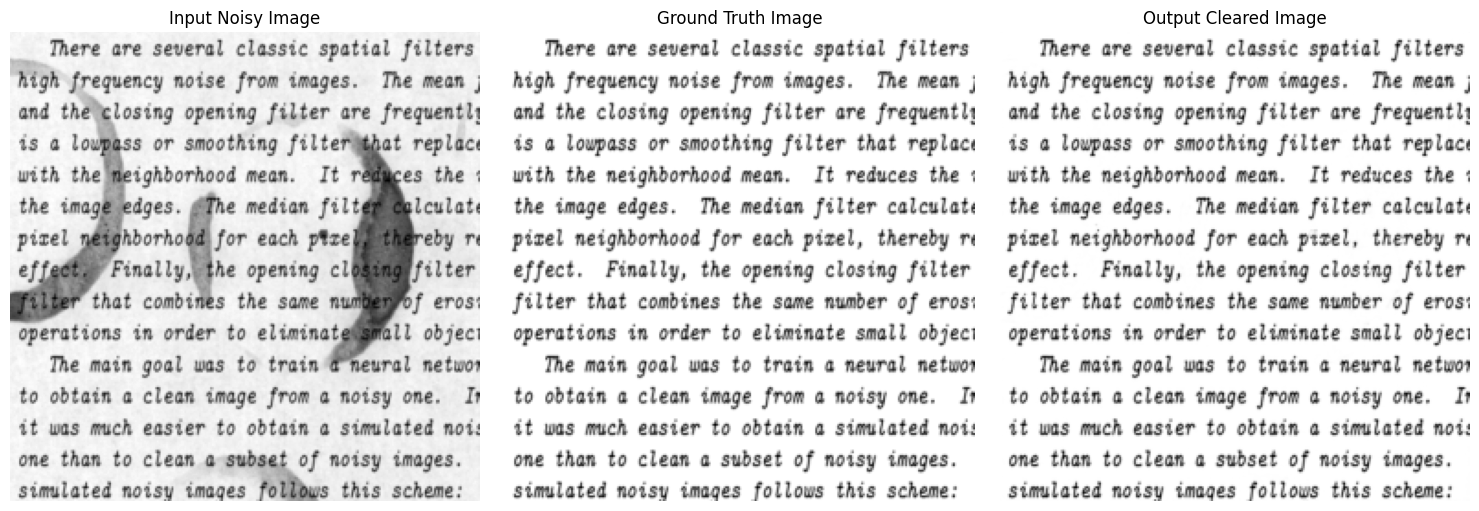

In [10]:
def visualise(model, dataloader, idx = 50):
  model.eval()
  noisy, clean = dataset[idx]
  noisy = noisy.unsqueeze(0).to(device)

  with torch.no_grad():
    output = model(noisy).squeeze(0).cpu()

  fig, axes = plt.subplots(1, 3, figsize=(15, 5))
  axes[0].imshow(dataset[idx][0].squeeze(0), cmap='gray')
  axes[0].set_title("Input Noisy Image")
  axes[1].imshow(dataset[idx][1].squeeze(0), cmap='gray')
  axes[1].set_title("Ground Truth Image")
  axes[2].imshow(output.squeeze(0), cmap='gray')
  axes[2].set_title("Output Cleared Image")
  for ax in axes:
    ax.axis('off')
  plt.tight_layout()
  plt.show()


visualise(model, dataloader, idx = 50)